# Extended Data 04 | Defense-spillover sensitivity

This notebook evaluates the revised instrumental-variable design after imposing high-exposure eligibility **before** within-fire rematching. It tests spatial dependence, isolation from other defended structures, the upstream-destruction threshold, the arrival window, the neighbor radius, propensity-score overlap and covariate balance.

In [2]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
PACKAGE_ROOT = next(
    (path for path in candidates
     if (path / 'data').exists() and (path / 'src').exists()
     and (path / 'notebooks').exists()),
    None,
)
if PACKAGE_ROOT is None:
    raise RuntimeError('Run from the reproduction-package root or a notebook subdirectory')
PROJECT_ROOT = PACKAGE_ROOT
sys.path.insert(0, str(PACKAGE_ROOT))

import pandas as pd
from IPython.display import display

from src.analysis.defense import (
    covariate_balance, prepare_spillover_match
)
from src.analysis.defense_sensitivity import (
    add_pair_spatial_context, design_sensitivity,
    propensity_overlap_table, spatial_and_isolation_table,
    threshold_sensitivity,
)
from src.viz.defense_sensitivity import plot_defense_sensitivity

RESULTS = PACKAGE_ROOT / 'results'
DERIVED = PACKAGE_ROOT / 'data' / 'derived'
FIGURES = PACKAGE_ROOT / 'figures' / 'extended_data'
for directory in [RESULTS, DERIVED, FIGURES]:
    directory.mkdir(parents=True, exist_ok=True)
N_BOOT = 2000
SENSITIVITY_BOOT = 1000
SEED = 20250810

## Restricted and rematched IV population

The primary population requires at least 75% of up-fire neighbors to have been destroyed and observed outcomes among undefended neighbors within 100 ft in both directions. Propensity-score matching is then repeated within this population.

In [3]:
focal = pd.read_parquet(DERIVED / 'defense_focal_table.parquet')
eligible, matched, propensity_model = prepare_spillover_match(
    focal, threshold=.75
)
balance = covariate_balance(eligible, matched)
balance.to_csv(RESULTS / 'ED04_defense_iv_balance.csv', index=False)
print(f'eligible: {len(eligible):,}; defended: {eligible.defended.sum():,}')
print(f'matched pairs: {matched.pair_id.nunique():,}')
print(f'maximum absolute post-match SMD: {balance.smd_after.abs().max():.3f}')
display(balance.round(3))

eligible: 10,122; defended: 225
matched pairs: 225
maximum absolute post-match SMD: 0.057


,covariate,smd_before,smd_after
0,up_share,-0.133,-0.014
1,l_F_upfire_wmean,-0.100,-0.053
2,l_F_total_wmean,0.044,-0.057
3,n_destroyed_bldgs,-0.266,-0.022
4,l_n_neighbors_500ft,-0.436,0.030
5,wind_speed_arrival_mph,0.244,0.003
6,arrival,0.046,-0.047
7,elevation,-0.184,0.028
8,ndvi_mean,-0.184,0.044


## Spatial dependence and isolated defense

Each matched pair is assigned to the 250-m grid cell of its defended focal structure. The spatial bootstrap resamples these cells within fire while retaining complete pairs. A defended focal is classified as isolated when the nearest other documented defended structure in the focal population is more than 150 m away.

In [4]:
context = add_pair_spatial_context(
    PROJECT_ROOT, focal, matched, block_m=250, isolation_m=150
)
spatial = spatial_and_isolation_table(
    context, n_boot=N_BOOT, seed=SEED
)
spatial.to_csv(RESULTS / 'ED04_defense_spatial_isolation.csv', index=False)
display(spatial.round(3))

,analysis,n,pairs,spatial_blocks,defended_n,first_stage,directional_contrast,directional_lo,directional_hi,local_iv,local_iv_lo,local_iv_hi
0,Primary: matched-pair bootstrap,450,225,103,225,0.267,-0.134,-0.205,-0.060,-0.502,-0.887,-0.216
1,Primary: 250-m block bootstrap,450,225,103,225,0.267,-0.134,-0.208,-0.059,-0.502,-0.921,-0.217
2,Isolated defense (>150 m),36,18,17,18,0.722,-0.420,-0.648,-0.184,-0.582,-1.117,-0.218
3,Clustered defense (<=150 m),414,207,89,207,0.227,-0.109,-0.186,-0.031,-0.480,-1.025,-0.142


## Upstream-destruction threshold

The high-exposure definition is varied from 60% to 90%. Eligibility and matching are recomputed at every threshold.

In [5]:
threshold = threshold_sensitivity(
    focal, thresholds=(.60, .70, .75, .80, .90),
    n_boot=SENSITIVITY_BOOT, seed=SEED
)
threshold.to_csv(RESULTS / 'ED04_defense_threshold_sensitivity.csv', index=False)
display(threshold.round(3))

,upstream_destroyed_threshold,eligible_n,pairs,max_abs_smd,first_stage,directional_contrast,directional_lo,directional_hi,local_iv,local_iv_lo,local_iv_hi
0,0.60,12335,304,0.053,0.355,-0.088,-0.156,-0.024,-0.249,-0.444,-0.070
1,0.70,10827,245,0.115,0.380,-0.139,-0.204,-0.072,-0.365,-0.557,-0.182
2,0.75,10122,225,0.057,0.267,-0.134,-0.204,-0.068,-0.502,-0.938,-0.236
3,0.80,9138,198,0.168,0.258,-0.082,-0.162,-0.006,-0.318,-0.643,-0.027
4,0.90,6462,128,0.133,0.328,-0.089,-0.164,-0.021,-0.271,-0.533,-0.062


## Arrival window and neighborhood radius

The primary ±3-hour, 100-ft design is compared with ±1.5- and ±6-hour arrival windows and 50- and 150-ft neighbor radii. The focal table and match are rebuilt for every specification; cached focal tables avoid repeated scans on subsequent runs.

In [6]:
design = design_sensitivity(
    PROJECT_ROOT, focal, DERIVED / 'ED04_design_cache',
    n_boot=SENSITIVITY_BOOT, seed=SEED
)
design.to_csv(RESULTS / 'ED04_defense_design_sensitivity.csv', index=False)
display(design.round(3))

,design,arrival_window_h,neighbor_radius_ft,eligible_n,pairs,max_abs_smd,first_stage,directional_contrast,directional_lo,directional_hi,local_iv,local_iv_lo,local_iv_hi
0,Arrival window: 1.5 h,1.5,100,10258,226,0.087,0.327,-0.114,-0.181,-0.048,-0.349,-0.579,-0.140
1,"Primary: 3 h, 100 ft",3.0,100,10122,225,0.057,0.267,-0.134,-0.213,-0.062,-0.502,-0.932,-0.213
2,Arrival window: 6 h,6.0,100,10121,225,0.096,0.316,-0.082,-0.155,-0.009,-0.261,-0.497,-0.033
3,Neighbor radius: 50 ft,3.0,50,7622,101,0.133,0.396,-0.082,-0.207,0.036,-0.208,-0.529,0.103
4,Neighbor radius: 150 ft,3.0,150,11000,300,0.128,0.273,-0.101,-0.153,-0.046,-0.370,-0.621,-0.173


### Sensitivity summary table

*Supplement — Extended Data Table.*

The threshold and design sensitivities are combined into one table so that the
range quoted in the results section is reproducible from a single output
rather than assembled by hand from two files. The primary specification
appears once, and each remaining row alters exactly one design choice while
holding the others fixed. The caption computes the range, median and the
count of specifications whose interval excludes zero, so those summary figures
cannot drift from the underlying estimates.

In [ ]:
# One Extended Data table over every design choice, so the range quoted in the
# text is reproducible rather than read off two separate files.
PRIMARY_LABEL = 'Primary: 75% threshold, ±3 h, 100 ft'
sensitivity_rows = []
for _, row in design.iterrows():
    primary = row.design.startswith('Primary')
    sensitivity_rows.append({
        'block': 'Primary specification' if primary else (
            'Arrival window' if 'window' in row.design
            else 'Neighbor radius'),
        'Specification': PRIMARY_LABEL if primary else row.design.split(': ')[1],
        'is_primary': primary, **row.to_dict()})
for _, row in threshold.iterrows():
    if np.isclose(row.upstream_destroyed_threshold, .75):
        continue  # the primary specification, already listed
    sensitivity_rows.append({
        'block': 'Upstream-destruction threshold',
        'Specification':
            f'{100 * row.upstream_destroyed_threshold:.0f}% of up-fire '
            'neighbors destroyed',
        'is_primary': False, **row.to_dict()})
defense_sensitivity_table = pd.DataFrame(sensitivity_rows)
defense_sensitivity_table['directional_pp'] = (
    100 * defense_sensitivity_table.directional_contrast)
defense_sensitivity_table.to_csv(
    RESULTS / 'ED04_defense_sensitivity_summary.csv', index=False)

BLOCK_ORDER = ['Primary specification', 'Arrival window', 'Neighbor radius',
               'Upstream-destruction threshold']
COLUMNS = [('eligible_n', 'Eligible focal structures', '{:,.0f}'),
           ('pairs', 'Matched pairs', '{:,.0f}'),
           ('max_abs_smd', 'Largest absolute SMD', '{:.3f}'),
           ('first_stage', 'First stage (pp)', '{:.1f}')]
lines = ['**Extended Data Table | Sensitivity of the down-fire spillover '
         'estimate to design choices.**', '',
         '| Specification | ' + ' | '.join(label for _, label, _ in COLUMNS)
         + ' | Direction-adjusted contrast, pp (95% CI) |',
         '|---|' + '|'.join([':--:'] * (len(COLUMNS) + 1)) + '|']
for block in BLOCK_ORDER:
    rows = defense_sensitivity_table[defense_sensitivity_table.block.eq(block)]
    if rows.empty:
        continue
    if block != 'Primary specification':
        lines.append(f'| **{block}** | ' + ' | '.join([''] * (len(COLUMNS) + 1))
                     + ' |')
    for _, row in rows.iterrows():
        contrast = (f'{100 * row.directional_contrast:.1f} '
                    f'({100 * row.directional_lo:.1f} to '
                    f'{100 * row.directional_hi:.1f})').replace('-', '−')
        cells = [fmt.format(row[key] * (100 if key == 'first_stage' else 1))
                 for key, _, fmt in COLUMNS]
        lines.append(f'| {row.Specification} | ' + ' | '.join(cells)
                     + f' | {contrast} |')

contrasts = 100 * defense_sensitivity_table.directional_contrast.abs()
protective = defense_sensitivity_table.directional_hi.lt(0)
lines += ['', (
    'Each row repeats the eligibility, matching and estimation pipeline with '
    'one design choice altered and the others held at the primary '
    'specification (75% up-fire destruction threshold, ±3 h arrival window, '
    '100 ft neighbor radius). The difference-in-differences is the down-fire '
    'minus up-fire contrast between defended structures and matched controls; '
    f'intervals are {SENSITIVITY_BOOT:,} bootstrap resamples of complete pairs '
    'within fire. SMD, standardized mean difference after matching; first '
    'stage, matched difference in focal-structure survival; pp, percentage '
    'points.')]
defense_sensitivity_markdown = '\n'.join(lines)
(RESULTS / 'ED04_defense_sensitivity_summary.md').write_text(
    defense_sensitivity_markdown + '\n', encoding='utf-8')

display(Markdown(defense_sensitivity_markdown))
print('across {} alternatives: {:.1f} to {:.1f} pp, median {:.1f}, excluding zero in {} of {}'.format(
    len(alternatives), contrasts.min(), contrasts.max(),
    contrasts.median(), int(protective.sum()), len(protective)))
print('saved', RESULTS / 'ED04_defense_sensitivity_summary.md')

## Overlap and composite figure

,sample,group,n,propensity_min,propensity_p05,propensity_median,propensity_p95,propensity_max,within_treated_range_share
0,Eligible,Undefended,9897,0.000,0.010,0.018,0.042,0.281,0.999
1,Eligible,Defended,225,0.005,0.013,0.024,0.079,0.217,1.000
2,Matched,Undefended,225,0.005,0.013,0.024,0.079,0.218,0.991
3,Matched,Defended,225,0.005,0.013,0.024,0.079,0.217,1.000


saved ./figures/extended_data/ED_fig_defense_spillover_sensitivity.pdf


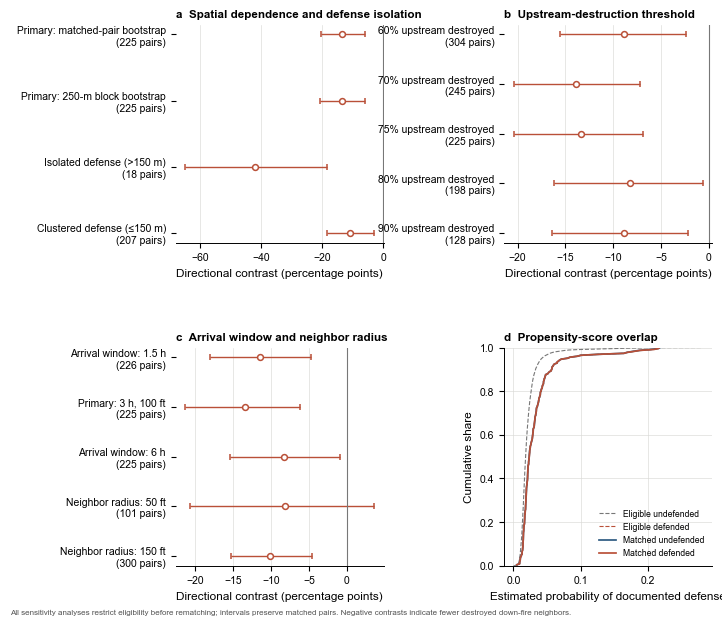

In [ ]:
overlap = propensity_overlap_table(eligible, matched)
overlap.to_csv(RESULTS / 'ED04_defense_propensity_overlap.csv', index=False)
display(overlap.round(3))

fig = plot_defense_sensitivity(
    spatial, threshold, design, eligible, matched, FIGURES
)
print('saved', FIGURES / 'ED_fig_defense_spillover_sensitivity.pdf')

## Interpretation

The pooled directional contrast remained negative under 250-m spatial-block resampling and across upstream-destruction thresholds from 60% to 90%, arrival windows from 1.5 to 6 hours and a 150-ft neighbor radius. The estimate among isolated defended structures was also negative, although only 18 isolated pairs qualified. At 50 ft, the estimate remained negative but its interval crossed zero and only 101 pairs remained. Propensity-score distributions were nearly identical after matching, and 99% of matched controls fell within the defended score range. Some alternative thresholds and radii had post-match standardized differences above 0.10 and should therefore be interpreted as qualitative sensitivity checks. The local IV ratio is less stable than the direction-corrected contrast because it also depends on the estimated first stage.

## Alternative Eaton progression reconstructions

The primary defense analysis uses method **c**, the kriging update to the interpolated Eaton progression surface. Here, the complete analysis is repeated using method **b** (linear interpolation between cumulative fire fronts) and method **d** (direct regression kriging of isochrone boundaries and timeline observations). Palisades timing is unchanged because its progression surface is observation based. For Eaton, both arrival ordering and the corresponding area-weighted up-fire exposure are recomputed; all matching rules, outcome definitions, covariates, thresholds and bootstrap settings are otherwise fixed.

In [ ]:
from src.analysis.progression_sensitivity import (
    progression_range_table, run_progression_sensitivity,
)
from src.viz.progression_sensitivity import plot_progression_sensitivity

progression = run_progression_sensitivity(
    PROJECT_ROOT, n_boot=N_BOOT, seed=20250809
)
for name, table in progression.items():
    table.to_csv(
        RESULTS / f'ED04_defense_progression_{name}.csv', index=False
    )
progression_ranges = progression_range_table(progression)
progression_ranges.to_csv(
    RESULTS / 'ED04_defense_progression_ranges.csv', index=False
)
display(progression['audit'].round(3))
display(progression['direct'].query("sample == 'Pooled'").round(3))
display(progression['spillover'].query("sample == 'Pooled'").round(3))
display(progression_ranges.round(2))

,method,progression_method,eligible_focal_n,eligible_defended_n,direct_matched_pairs,spillover_eligible_n,spillover_matched_pairs,max_abs_postmatch_smd
0,b,Linear interpolation,24614,1178,1176,10133,210,0.103
1,c,Kriging update (primary),24494,1168,1167,10122,225,0.057
2,d,Direct regression kriging,24511,1181,1181,9955,214,0.046


,method,progression_method,sample,matched_pairs,survival_difference_pp,ci_lo,ci_hi,p_value
0,b,Linear interpolation,Pooled,1176,11.139,7.168,15.307,0.0
3,c,Kriging update (primary),Pooled,1167,13.539,9.595,17.711,0.0
6,d,Direct regression kriging,Pooled,1181,11.346,7.292,15.494,0.0


,method,progression_method,sample,n,defended_n,first_stage,first_stage_F,downfire_contrast,downfire_contrast_lo,downfire_contrast_hi,upfire_placebo,upfire_placebo_lo,upfire_placebo_hi,directional_contrast,directional_contrast_lo,directional_contrast_hi,local_iv,local_iv_lo,local_iv_hi
0,b,Linear interpolation,Pooled,420,210,0.248,34.714,-0.072,-0.132,-0.013,0.005,-0.040,0.051,-0.078,-0.145,-0.007,-0.314,-0.633,-0.027
3,c,Kriging update (primary),Pooled,450,225,0.267,41.627,-0.140,-0.199,-0.081,-0.006,-0.057,0.044,-0.134,-0.207,-0.058,-0.502,-0.883,-0.222
6,d,Direct regression kriging,Pooled,428,214,0.304,53.487,-0.138,-0.202,-0.075,-0.011,-0.053,0.032,-0.127,-0.199,-0.054,-0.419,-0.719,-0.178


,estimand,minimum_pp,maximum_pp,range_width_pp
0,Matched focal survival difference,11.14,13.54,2.40
1,Direction-adjusted neighbor contrast,-13.40,-7.78,5.62
2,Local IV ratio,-50.23,-31.41,18.83
3,Earlier-arrival defended-view AME,-1.81,-1.10,0.70
4,Later-arrival defended-view control AME,-0.97,-0.77,0.20
5,Earlier-arrival AME after destroyed-share adju...,0.36,0.73,0.37


saved ./figures/extended_data/ED_fig_defense_progression_map_sensitivity.pdf


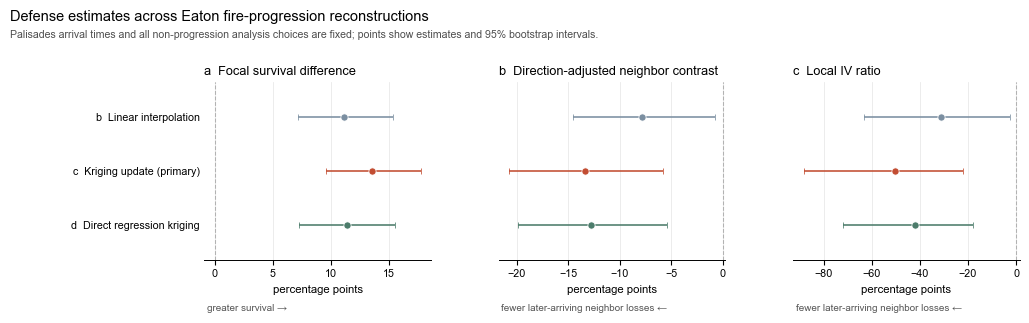

In [ ]:
fig = plot_progression_sensitivity(progression, FIGURES)
print('saved', FIGURES / 'ED_fig_defense_progression_map_sensitivity.pdf')

### Interpretation

The pooled focal-survival association remained positive across all progression maps (11.1–13.5 percentage points). The direction-adjusted neighbor contrast also remained protective (−7.8 to −13.4 points), and its 95% bootstrap interval excluded zero for every reconstruction. The local IV ratio ranged from −31.4 to −50.2 points and therefore remains less stable than the underlying neighbor contrast because it also depends on the first-stage survival difference.

The mechanism decomposition was less robust. Both earlier- and later-arrival defended-view terms were negative before adjustment under every map. After conditioning on the post-treatment destroyed share, the earlier-arrival term became positive and was statistically significant under methods b and d but not c. This does not support a definitive directional mechanism; it reinforces treating emitter removal as suggestive and the matched focal and direction-adjusted estimates as the more robust findings.